# Тюнинг линейной регрессии и ошибки

### О задании

В этом задании вы:
- обучите линейную регрессию, познакомитесь с метриками качества в задачах регресии

In [10]:
%pylab inline
import pandas as pd

from sklearn.base import BaseEstimator
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.11/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['f']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


## Часть 1. Линейная регрессия

Для начала загрузим данные и разделим их на обучающую и тестовую выборки в соотношении 7 к 3. Зачем так делать? Когда вы проверяете себя на данных на которых не обучались, вы можете быть уверены что не переобучились. Таким образом если качество на 70% датасета (оубчающей выборке) растёт, а на тестовой выборке падает, то модель начала запоминать датасет (переобучилась), вы что-то делаете не так.


In [11]:
data = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, train_size=0.7, random_state=241)

__Задание 1.__ Обучение линейной регрессии.

**(4 балла)**

Обучите линейную регрессию с $L_1$ (Lasso) и $L_2$ (Ridge) регуляризаторами (используйте параметры по умолчанию). Посмотрите, какое количество коэффициентов близко к 0 (степень близости к 0 определите сами из разумных пределов). Постройте график зависимости числа ненулевых коэффициентов от коэффицента регуляризации (перебирайте значения по логарифмической сетке от $10^{-3}$ до $10^3$).

Спойлер - при большом гиперпараметре регуляризации все параметры стремятся к нулю. На графике это должно быть видно.

In [12]:
from sklearn import datasets, linear_model
from sklearn.linear_model import Ridge, Lasso
import numpy as np

In [35]:
alphas = [
    m * (10 ** p)
    for p in range(-3, 4)
    for m in range(1, 10)
]

In [36]:
import math
from joblib import Parallel, delayed
from sklearn import linear_model

def count_coef_lasso(a):

    reg = linear_model.Lasso(alpha=a)
    reg.fit(X_train, y_train)
    reg.predict(X_test)
    return sum(1 for coef in reg.coef_ if coef < 0.1)

lasso_res = Parallel(n_jobs=-1)(delayed(count_coef_lasso)(alp) for alp in alphas)


def count_coef_ridge(a):

    reg2 = linear_model.Ridge(alpha=a)
    reg2.fit(X_train, y_train)
    reg2.predict(X_test)
    return sum(1 for coef in reg2.coef_ if abs(coef) < 5)

ridge_res = Parallel(n_jobs=-1)(delayed(count_coef_ridge)(alp) for alp in alphas)


In [32]:
#просто график как-то странно выглядит, ниже логарифмированный
# import matplotlib.pyplot as plt
# f, (ax) = plt.subplots(1, 1, figsize=(13, 5))
# ax.plot(np.array([i for i in alphas]), lasso_res, label='Lasso')
# ax.plot(np.array([i for i in alphas]), ridge_res, label='Ridge')
# ax.set_title(u"График")
# ax.set_xlabel(u"alpha")
# ax.set_ylabel(u"coef_reg")
# ax.grid()
# ax.legend()

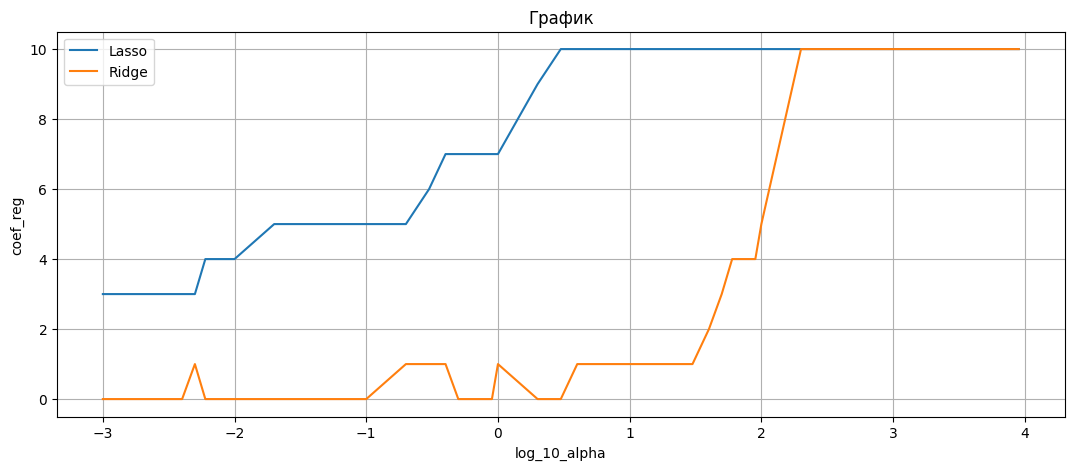

In [37]:
import matplotlib.pyplot as plt
f, (ax) = plt.subplots(1, 1, figsize=(13, 5))
ax.plot(np.array([math.log(i, 10) for i in alphas]), lasso_res, label='Lasso')
ax.plot(np.array([math.log(i, 10) for i in alphas]), ridge_res, label='Ridge')
ax.set_title(u"График")
ax.set_xlabel(u"log_10_alpha")
ax.set_ylabel(u"coef_reg")
ax.grid()
ax.legend()

Посчитайте для Ridge-регрессии следующие метрики: $RMSE$, $MAE$, $R^2$.

In [47]:
!pip install --upgrade scikit-learn

import sklearn
print(sklearn.__version__)

1.6.1


In [51]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
reg = linear_model.Ridge()
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
print(mean_squared_error(y_test, pred) ** 0.5)
print(mean_absolute_error(y_test, pred))
print(r2_score(y_test, pred))

58.30429511391227
49.602750809651916
0.3599020220009461


Подберите на обучающей выборке для Ridge-регрессии коэффициент регуляризации (перебирайте значения по логарифмической сетке от $10^{-3}$ до $10^3$) для каждой из метрик. Постройте графики зависимости фукнции потерь от коэффициента регуляризации. Посчитайте те же метрики снова. Заметно ли изменилось качество?

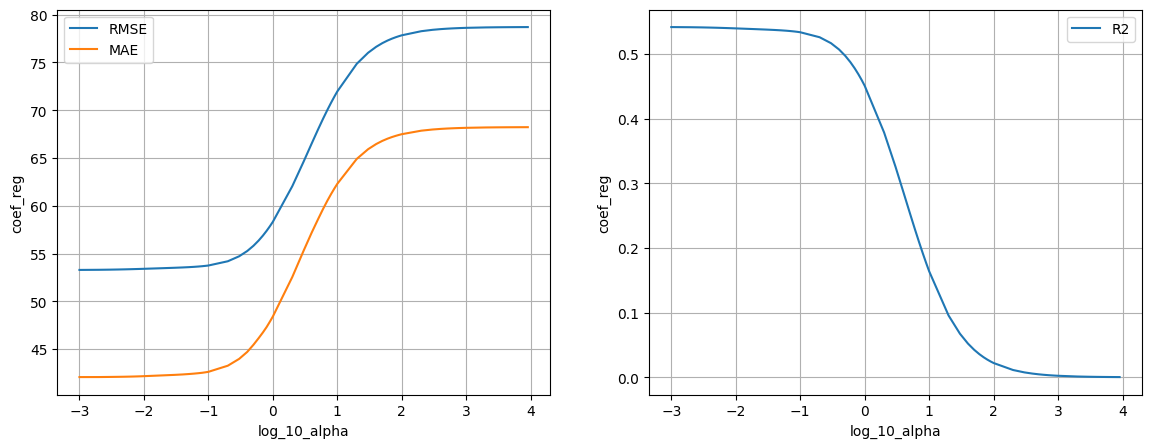

In [74]:
RMSEs, MAEs, R2s = [], [], []
for alp in alphas:
    reg = linear_model.Ridge(alpha=alp)
    reg.fit(X_train, y_train)
    pred = reg.predict(X_train)

    RMSEs.append(mean_squared_error(y_train, pred) ** 0.5)

    MAEs.append(mean_absolute_error(y_train, pred))

    R2s.append(r2_score(y_train, pred))


f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(np.array([math.log(i, 10) for i in alphas]), RMSEs, label='RMSE')
ax1.plot(np.array([math.log(i, 10) for i in alphas]), MAEs, label='MAE')
#ax1.plot(np.array([math.log(i, 10) for i in alphas]), R2s, label='R2') тут ниче нельзя понять из графика
ax1.set_xlabel(u"log_10_alpha")
ax1.set_ylabel(u"coef_reg")
ax2.plot(np.array([math.log(i, 10) for i in alphas]), R2s, label='R2')
ax2.set_xlabel(u"log_10_alpha")
ax2.set_ylabel(u"coef_reg")
ax1.grid()
ax1.legend()
ax2.grid()
ax2.legend()


In [71]:
reg = linear_model.Ridge(alpha=0.1)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
print(mean_squared_error(y_test, pred) ** 0.5)
print(mean_absolute_error(y_test, pred))
print(r2_score(y_test, pred))

55.64176122404913
47.375463757061304
0.41702880920983465


__Задание 2.__ Поиск объектов-выбросов

**(4 балла)**

Как известно, MSE сильно штрафует за большие ошибки на объектах-выбросах. Посчитайте ошибки и посмотрите на их распределение (plt.hist). Что вы видите?

In [ ]:
# code here

Попробуйте удалить объекты-выбросы из обучающей выборки (что считать или не считать выбросами на ваше усмотрение). Обучите модель заново и посмотрите на качество на отложенной выборке (учитывайте, что там тоже могут быть выбросы, с которыми вы ничего не можете сделать). Стало ли лучше? Чем вы можете объяснить это?

In [ ]:
# code here

__Задание 3.__ Отчёт

**(2 балла)**

 Обучили модели линейной регрессии с L1 (Lasso) и L2 (Ridge) регуляризацией, выявили, что Lasso обнуляет большее количество коэффициентов. Построили графики зависимости числа ненулевых коэффициентов от коэффициента регуляризации, демонстрирующие ожидаемое уменьшение количества ненулевых коэффициентов с ростом регуляризации. Для Ridge-регрессии рассчитали метрики RMSE, MAE и R2.  Подбор коэффициента регуляризации для Ridge на обучающей выборке улучшил метрики, что заметно по графикам зависимости функции потерь от коэффициента регуляризации и итоговым значениям метрик.